# 威斯康辛州乳腺癌数据集分类实验
## (合肥工业大学宣城校区机器学习小组成员刘思一2023218151)

本 Notebook 使用 Kaggle 平台的 Breast Cancer Wisconsin (Diagnostic) Data Set，对肿瘤诊断结果进行二分类预测。目标变量 `diagnosis` 中，`M` 表示恶性肿瘤，`B` 表示良性肿瘤。

本实验采用 scikit-learn 完成数据清洗、训练集/测试集划分、模型训练、分类评价和可视化。我们比较 4 种分类方法：

- Logistic Regression（逻辑回归）
- SVM（支持向量机）
- Random Forest（随机森林）
- KNN（K 近邻）

参考 Kaggle 和公开 GitHub Notebook 的常见流程，本实验保留本地 `data.csv` 作为完整训练数据，并使用我们自己的代码实现可复现实验。

## 1. 导入依赖

这里导入数据处理、可视化、模型评价相关库，并从 `src/breast_cancer_pipeline.py` 导入已经封装好的数据清洗和模型训练函数。这样 Notebook 主要负责展示过程，核心逻辑也可以通过自动化测试验证。

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, roc_curve

from src.breast_cancer_pipeline import (
    build_models,
    evaluate_models,
    load_dataset,
    load_raw_dataset,
    metrics_dataframe,
    split_dataset,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", palette="Set2")

# 配置中文字体，避免标题和坐标轴中的中文显示为方框。
plt.rcParams["font.sans-serif"] = [
    "Hiragino Sans GB",
    "Arial Unicode MS",
    "STHeiti",
    "PingFang SC",
    "SimHei",
    "DejaVu Sans",
]
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.unicode_minus"] = False

DATA_PATH = Path("data.csv")

## 2. 读取原始数据

Kaggle 原始 CSV 包含 `id`、`diagnosis`、30 个数值特征，以及末尾一个空列。建模时需要删除 `id` 和空列，只保留 30 个医学特征。

In [2]:
raw_df = load_raw_dataset(DATA_PATH)
print(f"原始数据维度: {raw_df.shape[0]} 行, {raw_df.shape[1]} 列")
raw_df.head()

原始数据维度: 569 行, 33 列


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

## 3. 数据清洗与标签编码

处理步骤如下：

- 删除 `id` 列，因为它只是样本编号，不应参与建模。
- 删除空列或 `Unnamed` 列。
- 将诊断结果编码为二分类数值：`B -> 0`，`M -> 1`。
- 保留 30 个连续型特征作为模型输入。

In [4]:
X, y, feature_names = load_dataset(DATA_PATH)
cleaned_df = X.copy()
cleaned_df["diagnosis"] = y

print(f"清洗后特征矩阵: {X.shape}")
print(f"标签分布: {y.value_counts().to_dict()}  # 0=良性, 1=恶性")
cleaned_df.head()

清洗后特征矩阵: (569, 30)
标签分布: {0: 357, 1: 212}  # 0=良性, 1=恶性


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## 4. 探索性数据分析与可视化

先观察类别分布。这个数据集共有 569 条样本，其中良性样本多于恶性样本，但比例没有极端失衡。

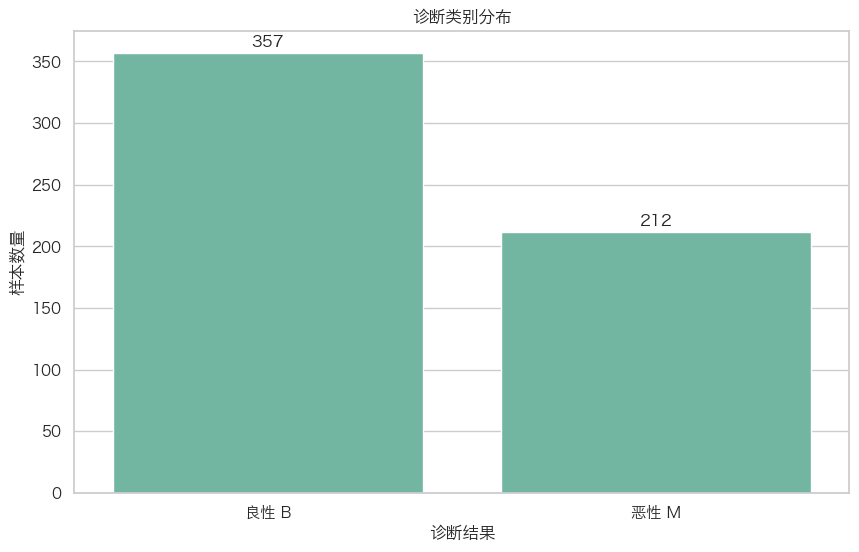

In [5]:
label_counts = y.map({0: "良性 B", 1: "恶性 M"}).value_counts()

ax = sns.barplot(x=label_counts.index, y=label_counts.values)
ax.set_title("诊断类别分布")
ax.set_xlabel("诊断结果")
ax.set_ylabel("样本数量")

for index, value in enumerate(label_counts.values):
    ax.text(index, value + 5, str(value), ha="center")

plt.show()

下面绘制 30 个特征的相关性热力图。可以看到，半径、周长、面积等特征之间相关性较高，这符合医学测量上的直觉。

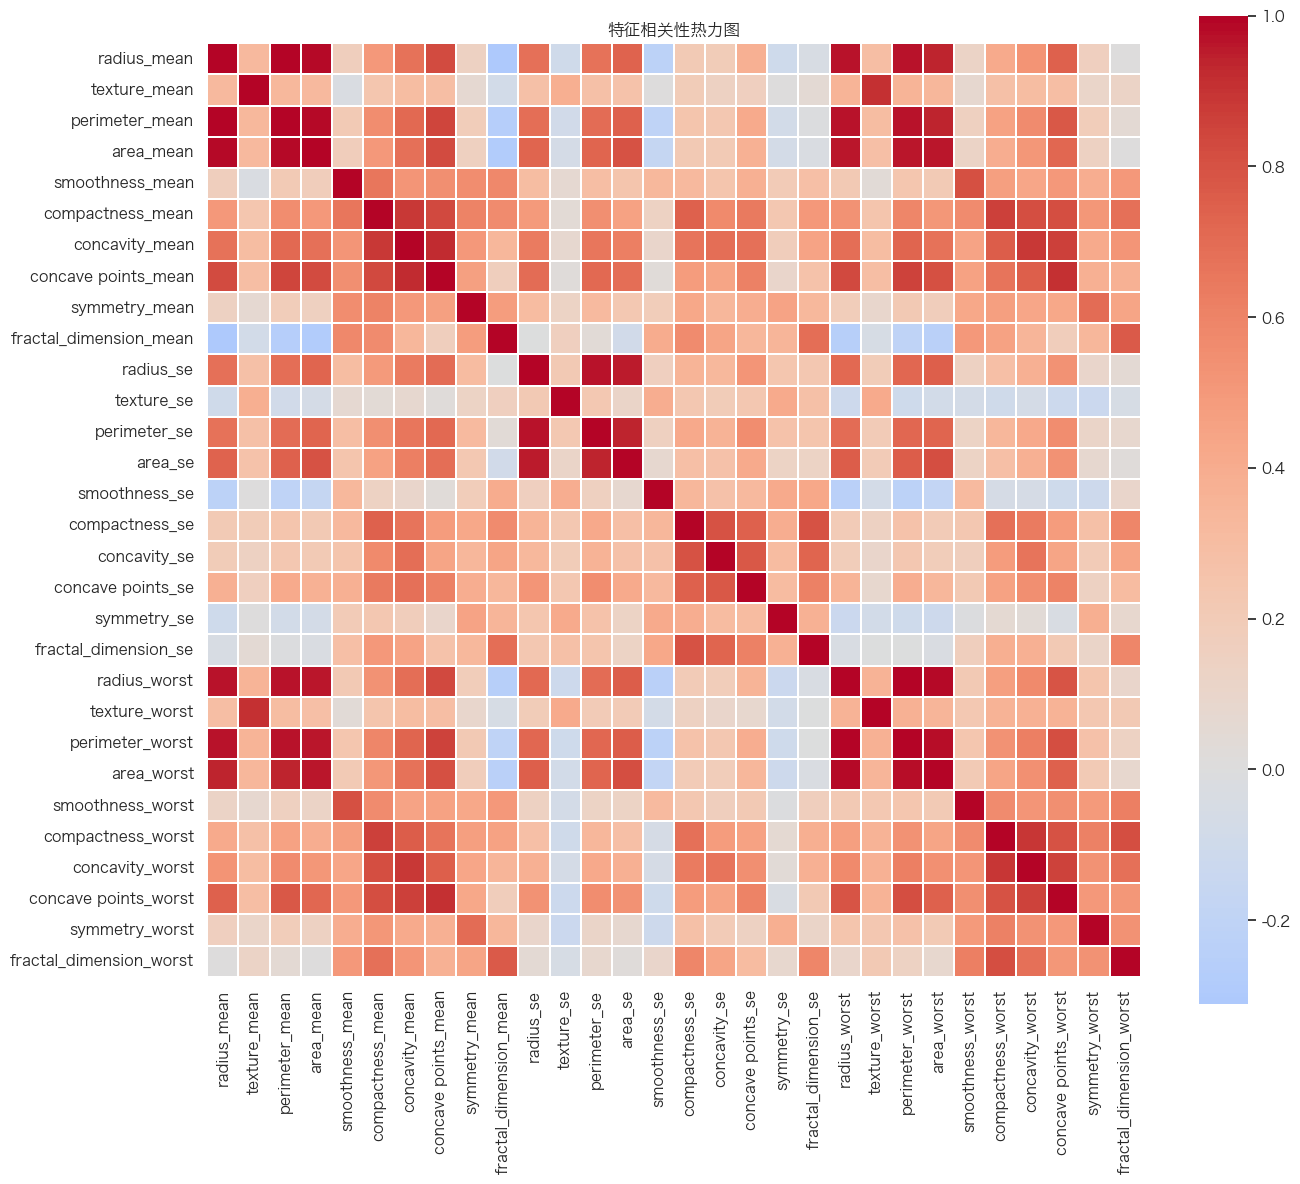

In [6]:
corr = X.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, linewidths=0.2)
plt.title("特征相关性热力图")
plt.tight_layout()
plt.show()

选取几个常见且区分度较明显的特征，比较良性和恶性样本的分布差异。箱线图能直观看出恶性样本在半径、周长、面积等指标上通常更高。

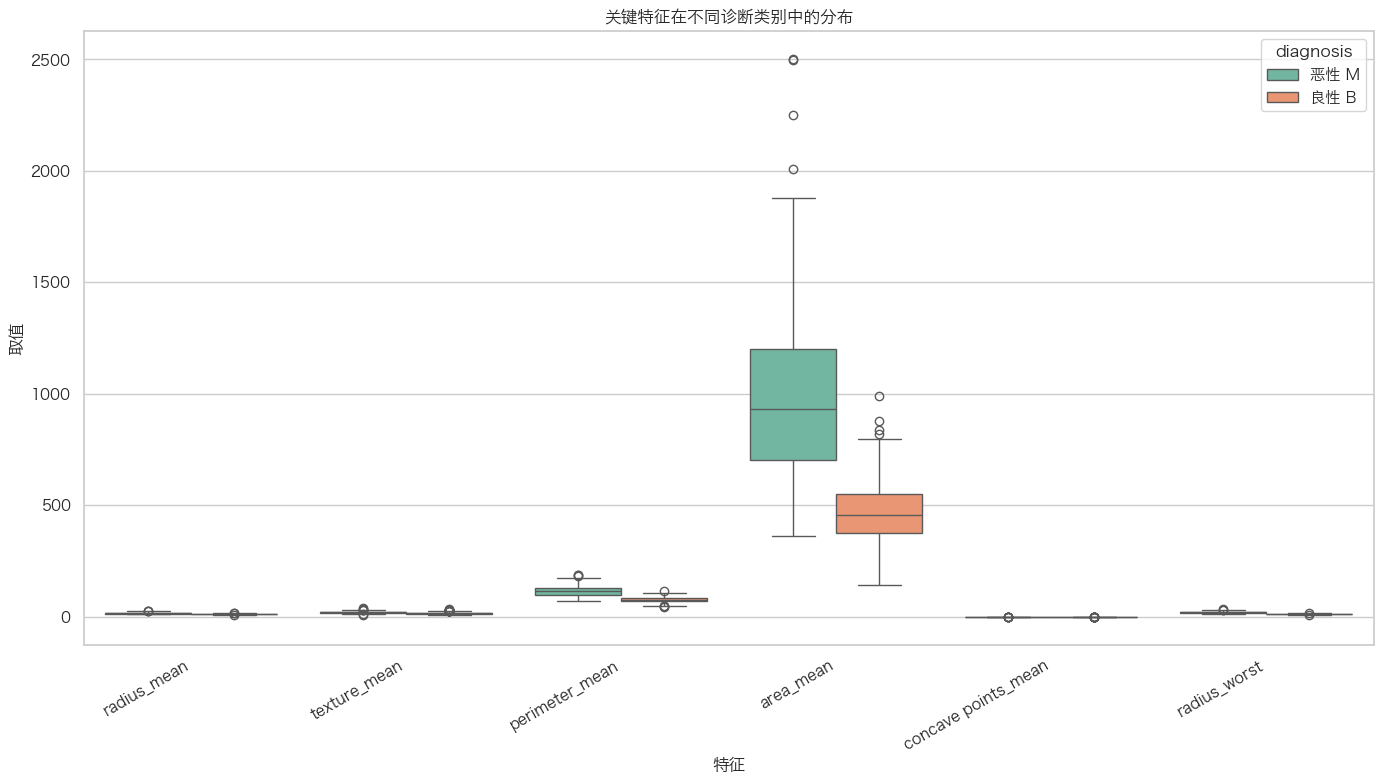

In [7]:
plot_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "concave points_mean",
    "radius_worst",
]

feature_plot_df = cleaned_df[plot_features + ["diagnosis"]].copy()
feature_plot_df["diagnosis"] = feature_plot_df["diagnosis"].map({0: "良性 B", 1: "恶性 M"})
long_df = feature_plot_df.melt(id_vars="diagnosis", var_name="feature", value_name="value")

plt.figure(figsize=(14, 8))
sns.boxplot(data=long_df, x="feature", y="value", hue="diagnosis")
plt.title("关键特征在不同诊断类别中的分布")
plt.xlabel("特征")
plt.ylabel("取值")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 5. 划分训练集和测试集

使用分层抽样划分数据，测试集比例为 20%。分层抽样可以保持训练集和测试集中良性/恶性样本比例接近原始数据。

In [8]:
X_train, X_test, y_train, y_test = split_dataset(X, y)

print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")
print("训练集标签分布:", y_train.value_counts(normalize=True).round(3).to_dict())
print("测试集标签分布:", y_test.value_counts(normalize=True).round(3).to_dict())

训练集: (455, 30), 测试集: (114, 30)
训练集标签分布: {0: 0.626, 1: 0.374}
测试集标签分布: {0: 0.632, 1: 0.368}


## 6. 训练 4 个分类模型

本实验比较四种常见分类器：

- 逻辑回归：线性模型，解释性较好。
- SVM：适合中小规模数据，能处理非线性边界。
- 随机森林：集成树模型，能输出特征重要性。
- KNN：基于样本距离的非参数模型。

对 Logistic Regression、SVM、KNN 使用标准化流水线；随机森林不依赖特征尺度，因此直接训练。

In [9]:
models = build_models()
results = evaluate_models(models, X_train, X_test, y_train, y_test)
metrics_df = metrics_dataframe(results)

metrics_df

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.973684,0.975610,0.952381,0.963855,0.996032
1,SVM,0.973684,1.000000,0.928571,0.962963,0.994709
2,Random Forest,0.964912,1.000000,0.904762,0.950000,0.997024
3,KNN,0.956140,0.974359,0.904762,0.938272,0.982308


## 7. 模型指标对比

这里同时比较 Accuracy、Precision、Recall、F1 和 ROC-AUC。医学诊断任务中，Recall 也很重要，因为漏判恶性样本的风险较高；综合比较时可以重点关注 F1 和 ROC-AUC。

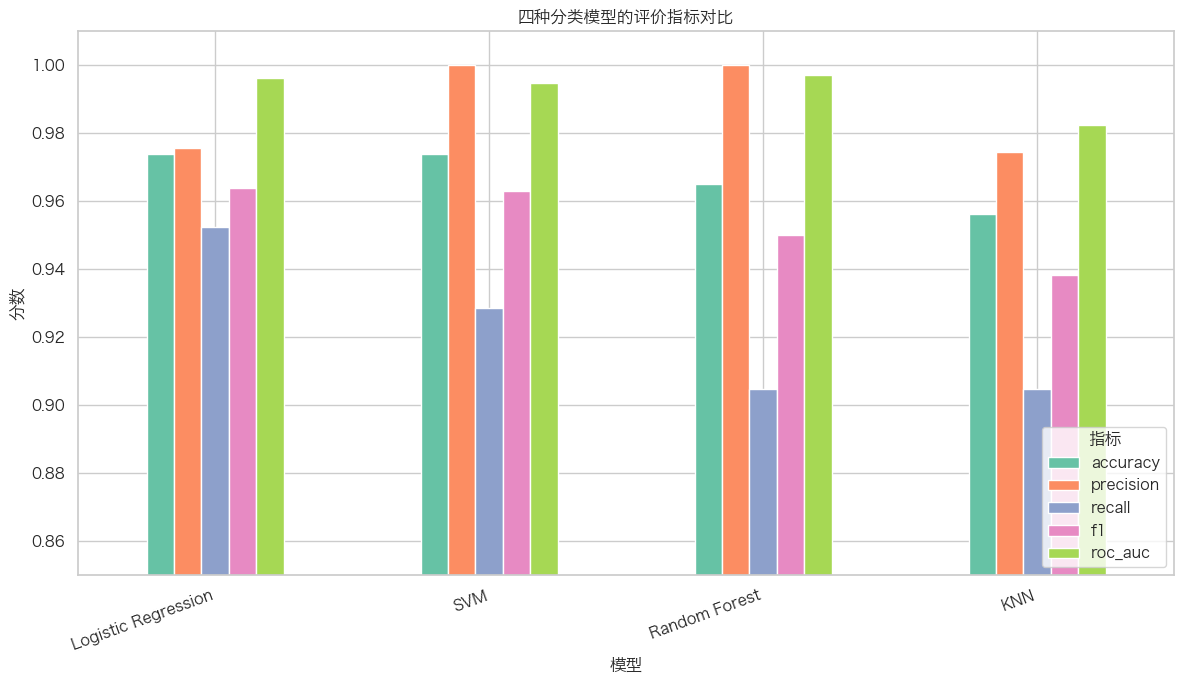

In [10]:
display_df = metrics_df.copy()
metric_columns = ["accuracy", "precision", "recall", "f1", "roc_auc"]

ax = display_df.set_index("model")[metric_columns].plot(kind="bar", figsize=(12, 7))
ax.set_title("四种分类模型的评价指标对比")
ax.set_xlabel("模型")
ax.set_ylabel("分数")
ax.set_ylim(0.85, 1.01)
ax.legend(title="指标", loc="lower right")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 8. 混淆矩阵

混淆矩阵展示每个模型在测试集上的预测细节：

- 左上：真实良性，预测良性。
- 右上：真实良性，预测恶性。
- 左下：真实恶性，预测良性。
- 右下：真实恶性，预测恶性。

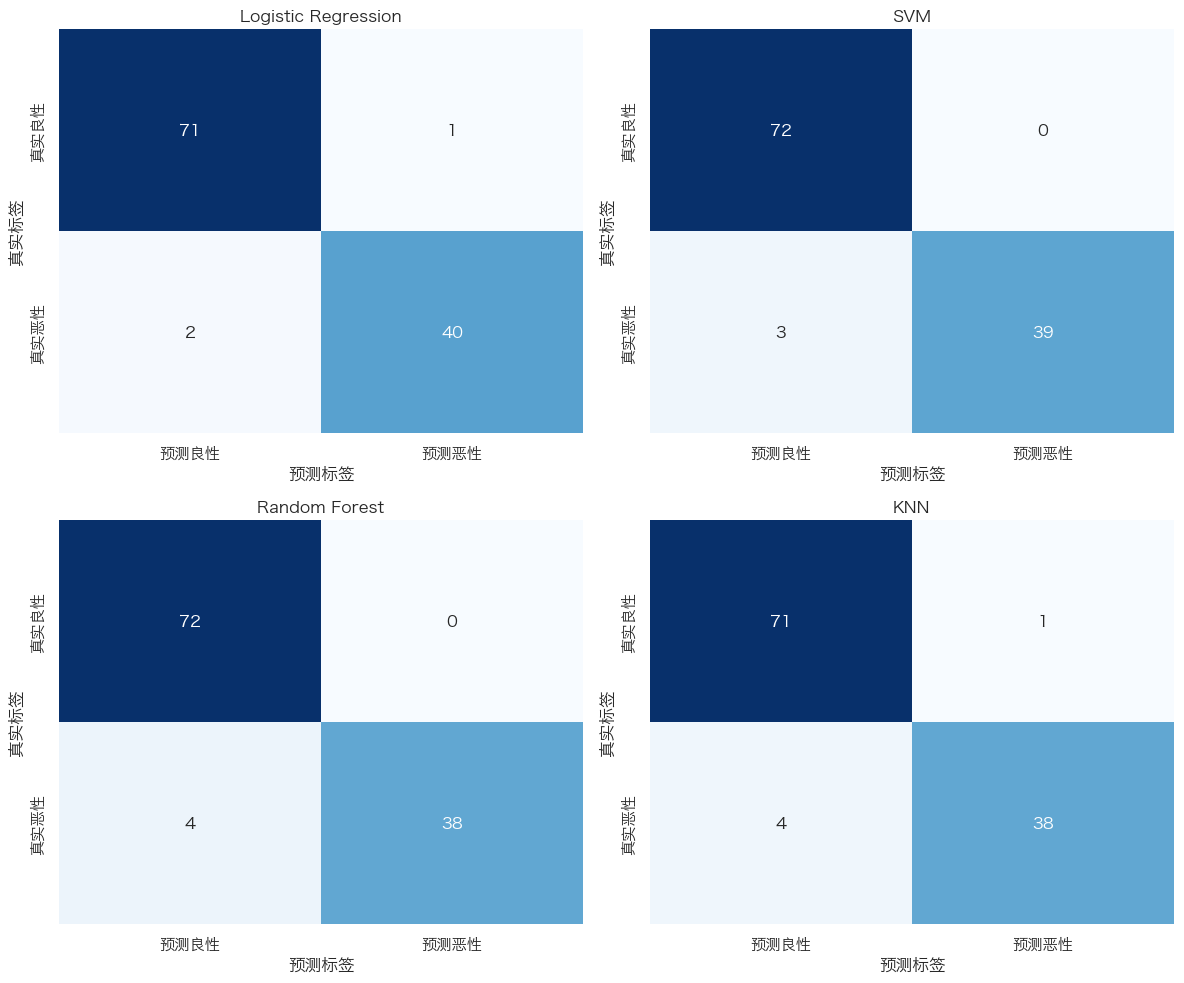

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, result) in zip(axes, results.items()):
    sns.heatmap(
        result.confusion_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["预测良性", "预测恶性"],
        yticklabels=["真实良性", "真实恶性"],
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("预测标签")
    ax.set_ylabel("真实标签")

plt.tight_layout()
plt.show()

## 9. ROC 曲线

ROC 曲线展示模型在不同分类阈值下的区分能力。曲线越靠近左上角，AUC 越高，模型越能区分良性和恶性样本。

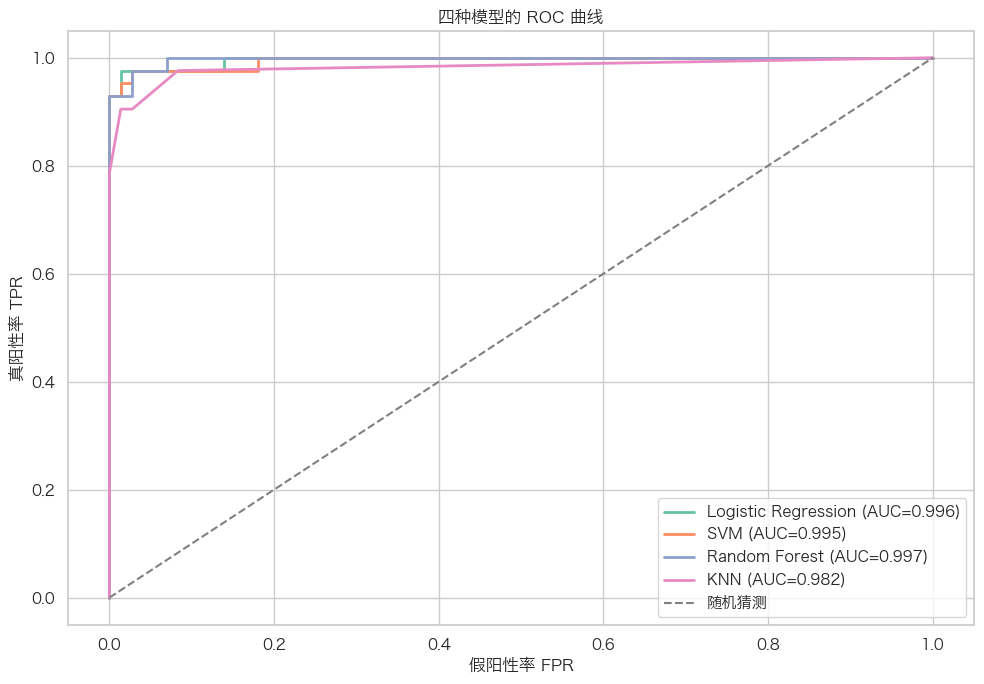

In [12]:
plt.figure(figsize=(10, 7))

for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result.y_score)
    auc_value = result.metrics["roc_auc"]
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="随机猜测")
plt.title("四种模型的 ROC 曲线")
plt.xlabel("假阳性率 FPR")
plt.ylabel("真阳性率 TPR")
plt.legend()
plt.tight_layout()
plt.show()

## 10. 随机森林特征重要性

随机森林可以给出特征重要性。下图展示贡献最高的前 12 个特征，有助于理解模型主要依赖哪些医学测量指标。

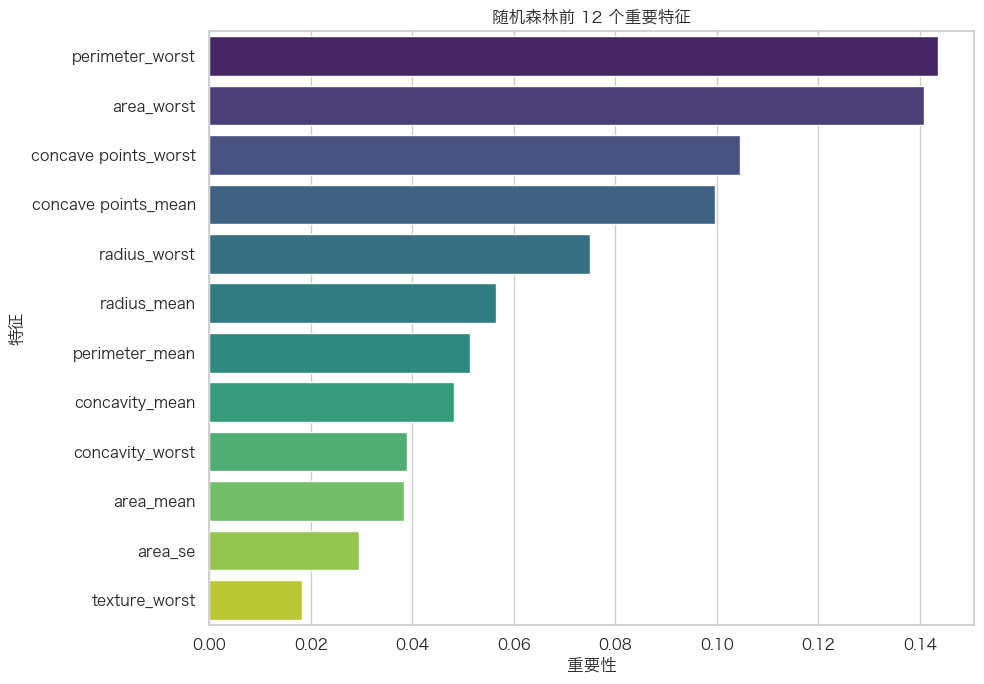

,feature,importance
22,perimeter_worst,0.143452
23,area_worst,0.140852
27,concave points_worst,0.104640
7,concave points_mean,0.099638
20,radius_worst,0.074969
0,radius_mean,0.056577
2,perimeter_mean,0.051317
6,concavity_mean,0.048216
26,concavity_worst,0.039018
3,area_mean,0.038366


In [13]:
rf_model = results["Random Forest"].model
importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": rf_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df.head(12), x="importance", y="feature", palette="viridis")
plt.title("随机森林前 12 个重要特征")
plt.xlabel("重要性")
plt.ylabel("特征")
plt.tight_layout()
plt.show()

importance_df.head(12)

## 11. 分类报告

下面输出每个模型的 precision、recall、f1-score 和 support。`1` 表示恶性样本，`0` 表示良性样本。

In [14]:
for name, result in results.items():
    print("=" * 80)
    print(name)
    print(classification_report(y_test, result.y_pred, target_names=["良性 B", "恶性 M"]))

Logistic Regression
              precision    recall  f1-score   support

        良性 B       0.97      0.99      0.98        72
        恶性 M       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

SVM
              precision    recall  f1-score   support

        良性 B       0.96      1.00      0.98        72
        恶性 M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

Random Forest
              precision    recall  f1-score   support

        良性 B       0.95      1.00      0.97        72
        恶性 M       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96   

## 12. 实验结论

从测试集结果看，四种 scikit-learn 分类器都能在该数据集上取得较高准确率，说明乳腺癌诊断数据中的 30 个数值特征具有较强区分能力。

一般来说：

- Logistic Regression 适合作为可解释性较强的基线模型。
- SVM 在标准化后通常表现稳定。
- Random Forest 能提供特征重要性，便于解释关键变量。
- KNN 简单直观，但对特征尺度敏感，因此必须标准化。

最终模型选择不应只看 Accuracy，还应结合 Recall、F1 和 ROC-AUC。对于乳腺癌诊断这类任务，减少恶性样本漏判尤其重要。